# Problem statement

Credit card fraud is a major challenge for financial institutions, resulting in significant financial losses and reduced customer trust. Fraudulent transactions represent only a very small fraction of all transactions, making the dataset highly imbalanced and difficult for traditional machine learning models to classify accurately. The goal of this project is to develop a robust machine learning model that can effectively distinguish fraudulent transactions from legitimate ones while minimizing false negatives and maintaining strong overall performance.

# Objective of credit card fraud analysis

- To analyze the credit card transaction dataset using Exploratory Data Analysis (EDA).
- To preprocess the data through data cleaning, feature engineering, and feature scaling.
- To build and compare multiple machine learning classification models for fraud detection.
- To address the class imbalance problem using SMOTE (Synthetic Minority Oversampling Technique).
- To evaluate model performance using metrics suitable for imbalanced datasets, including Precision, Recall, F1-score, ROC-AUC, PR-AUC, Balanced Accuracy, and MCC.
- To identify the best-performing model for accurately detecting fraudulent credit card transactions.

# Dataset summary

Feature	Summary
` Time : Time elapsed since the first transaction.
 `V1 – V28 : Anonymized numerical features generated using PCA to protect sensitive information.
`Amount : Transaction amount.
`Class : Target variable (0 = Legitimate, 1 = Fraudulent ).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
cc = pd.read_csv(r"C:\Users\franc\Downloads\creditcard.csv\creditcard.csv")


### Basic exploration

In [2]:
cc.info()
cc.head()
cc.shape
cc.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [3]:
cc.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [4]:
cc.duplicated().sum()

np.int64(1081)

In [5]:
duplicates=cc[cc.duplicated(keep=False)]
duplicates.sort_values(by=list(cc.columns))

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283485,171627.0,-1.457978,1.378203,0.811515,-0.603760,-0.711883,-0.471672,-0.282535,0.880654,0.052808,...,0.284205,0.949659,-0.216949,0.083250,0.044944,0.639933,0.219432,0.116772,11.93,0
284192,172233.0,-2.691642,3.123168,-3.339407,1.017018,-0.293095,-0.167054,-0.745886,2.325616,-1.634651,...,0.402639,0.259746,-0.086606,-0.097597,0.083693,-0.453584,-1.205466,-0.213020,36.74,0
284193,172233.0,-2.691642,3.123168,-3.339407,1.017018,-0.293095,-0.167054,-0.745886,2.325616,-1.634651,...,0.402639,0.259746,-0.086606,-0.097597,0.083693,-0.453584,-1.205466,-0.213020,36.74,0
284190,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0


In [6]:
cc = cc.drop_duplicates().reset_index(drop=True)

In [7]:
duplicates['Class'].value_counts()

Class
0    1822
1      32
Name: count, dtype: int64

In [8]:
cc = cc.drop_duplicates()
cc.shape

(283726, 31)

<Axes: xlabel='Class', ylabel='count'>

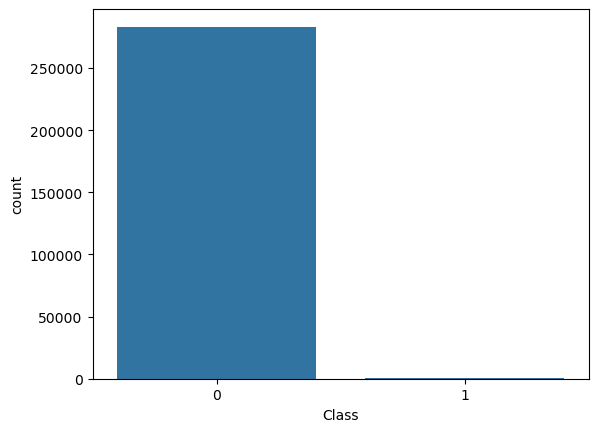

In [9]:
sns.countplot(x=cc["Class"])

#### Insight
- Legitimate transactions dominate the dataset.
- Fraud cases represent only a tiny fraction of all transactions.
- This indicates severe class imbalance.
- Detecting fraud is challenging because fraudulent behavior is rare.
#### Interpretation
- Even a small number of fraud transactions can lead to significant financial losses, making early detection critical.

In [10]:
cc["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

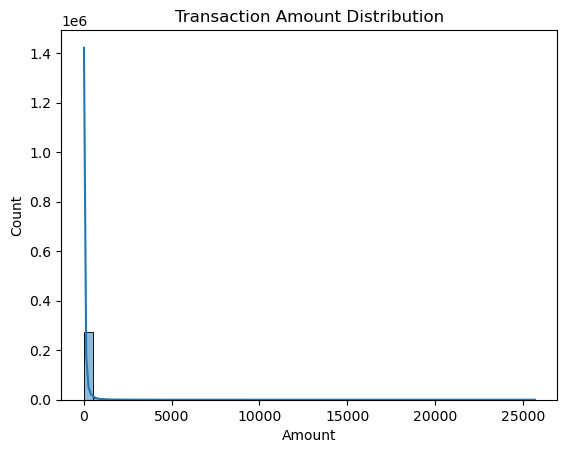

In [11]:
sns.histplot(cc['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

#### Insight
- Most transactions are low-value transactions.
- Distribution is heavily right-skewed.
- Few transactions involve extremely large amounts.
#### Interpretation
- Customers generally perform smaller transactions, while large transactions are uncommon and may require additional monitoring.

In [12]:
cc['Log_Amount'] = np.log1p(cc['Amount'])
cc['Log_Amount'] 

0         5.014760
1         1.305626
2         5.939276
3         4.824306
4         4.262539
            ...   
283721    0.570980
283722    3.249987
283723    4.232366
283724    2.397895
283725    5.384495
Name: Log_Amount, Length: 283726, dtype: float64

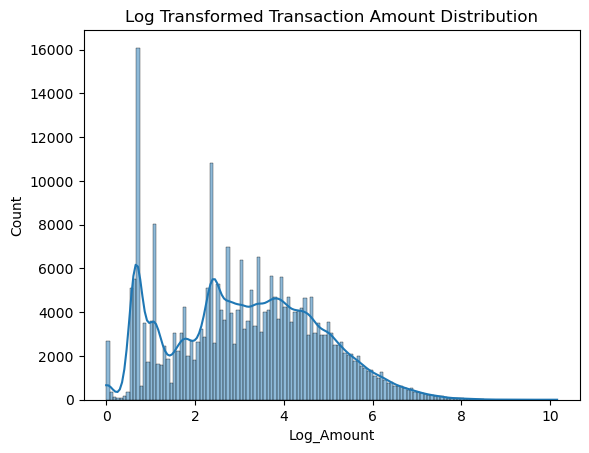

In [13]:
sns.histplot(cc['Log_Amount'], kde=True)
plt.title("Log Transformed Transaction Amount Distribution")
plt.show()

#### Insights
- The original transaction amount distribution was highly right-skewed, with a large concentration of small transactions and a few extremely high-value transactions. 
- After applying a log transformation, the distribution becomes more balanced and closer to a normal distribution, reducing the influence of extreme values.
#### Interpretation
- The log transformation reveals underlying transaction patterns that were previously masked by a small number of very large transactions. 
- This provides a clearer view of typical customer spending behavior and makes it easier to compare transaction groups without the analysis being dominated by outliers.

In [14]:
fraud_pct = cc['Class'].mean()*100
print(f"Fraudulent Transactions: {fraud_pct:.3f}%")

Fraudulent Transactions: 0.167%


<Axes: xlabel='Class', ylabel='Amount'>

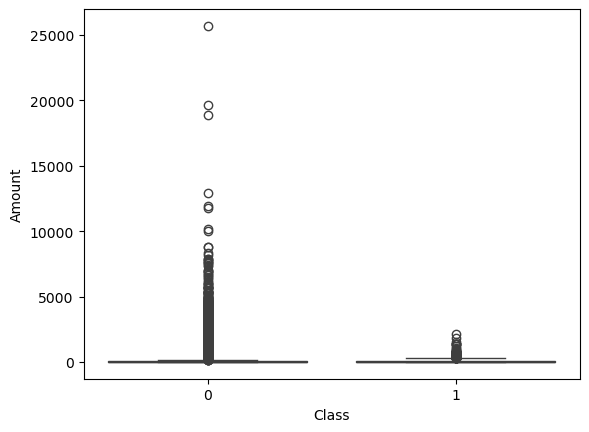

In [15]:
#comparing fraud vs non-fraud
sns.boxplot(x="Class", y="Amount", data = cc)

#### Insight
- Fraud and non-fraud transactions exhibit different spending patterns.
- Fraudulent transactions show greater variability in transaction amounts.
- Several extreme transaction values are present.
#### Interpretation
- Transaction amount alone cannot identify fraud, but unusual transaction amounts can serve as warning indicators.

In [16]:
cc.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


#### Insight
- Average transaction amounts differ between fraud and non-fraud groups.
- Fraud transactions may have unusual spending behavior compared to normal customers.
#### Interpretation
- Analyzing transaction value patterns can help identify suspicious financial activity.

<Axes: xlabel='Time', ylabel='Count'>

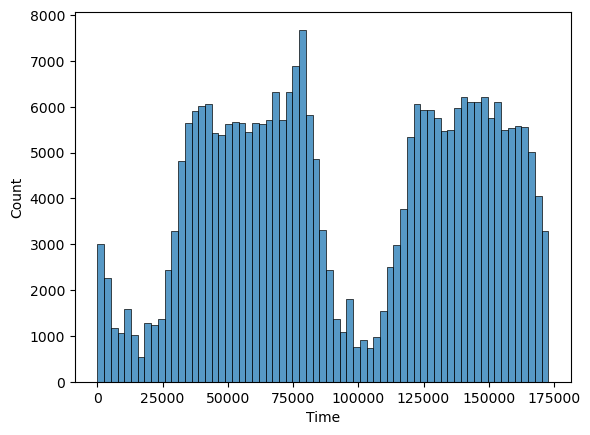

In [17]:
#time based analysis
sns.histplot(x=cc["Time"])

#### Insight
- Transaction activity is not uniformly distributed throughout the day.
- Certain time periods experience higher transaction volumes.
#### Interpretation
- Understanding customer activity patterns helps establish a baseline for detecting anomalies.


In [18]:
cc['Hour'] = (cc['Time'] // 3600) % 24
cc=cc.drop(columns = ["Time"])

In [19]:
fraud = cc[cc["Class"]==1]
legit =cc[cc["Class"]==0]
fraud_by_hour = fraud.groupby("Hour").size()
legit_by_hour = legit.groupby("Hour").size()
fraud_rate_by_hour = cc.groupby('Hour')['Class'].mean() * 100

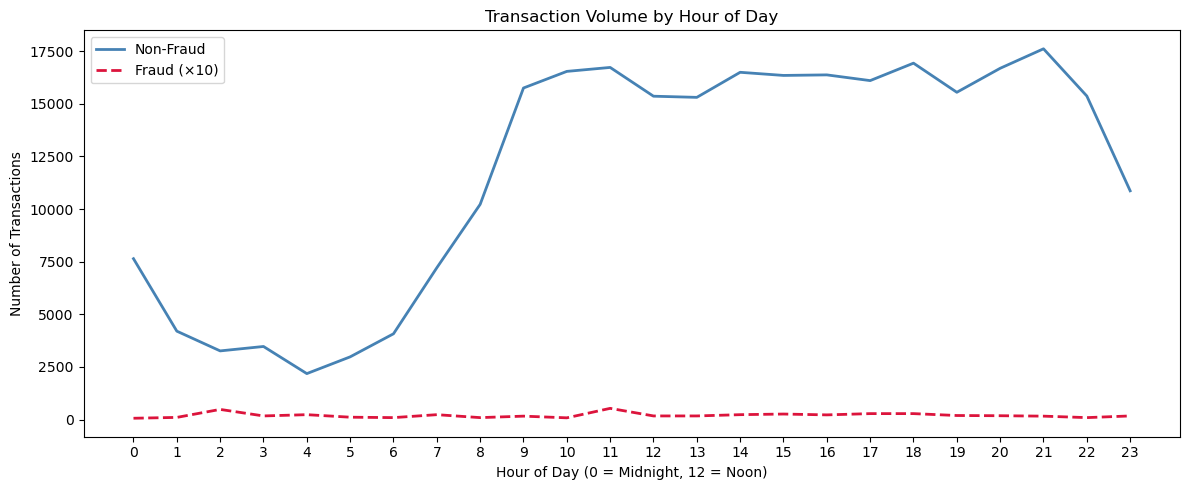

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(legit_by_hour.index, legit_by_hour.values, 
         label='Non-Fraud', color='steelblue', linewidth=2)
plt.plot(fraud_by_hour.index, fraud_by_hour.values * 10,  # scaled for visibility
         label='Fraud (×10)', color='crimson', linewidth=2, linestyle='--')
plt.title('Transaction Volume by Hour of Day')
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
plt.ylabel('Number of Transactions')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

#### Insight
- Legitimate transactions follow regular daily patterns.
- Fraudulent transactions occur throughout the day but may concentrate during specific periods.
#### Interpretation
- Fraudsters often exploit periods of reduced monitoring orlower customers activity

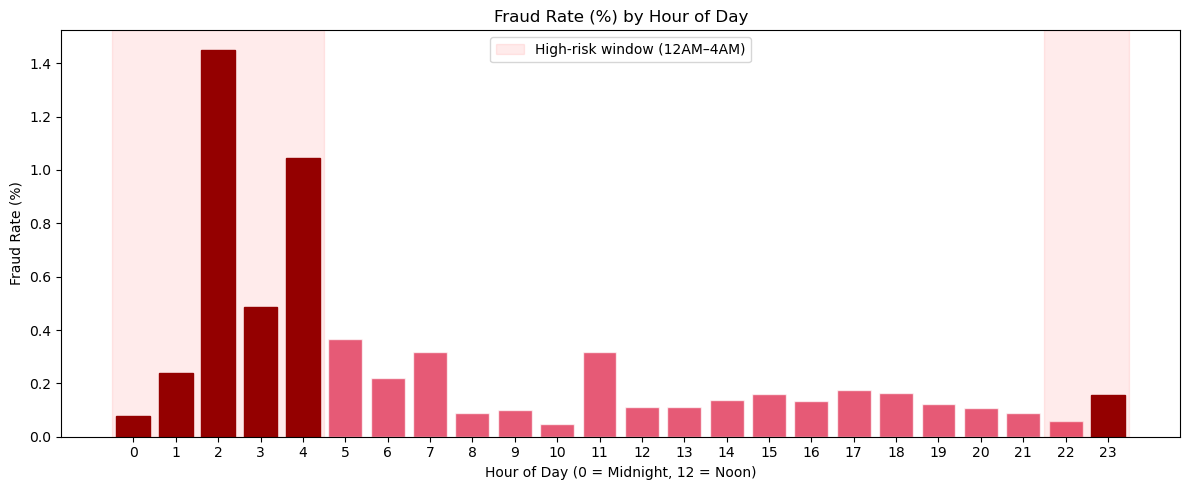

In [21]:
plt.figure(figsize=(12, 5))
bars = plt.bar(fraud_rate_by_hour.index, fraud_rate_by_hour.values,
               color='crimson', alpha=0.7, edgecolor='white')
for bar in bars:
    hour = bar.get_x()
    if hour <= 4 or hour >= 22:
        bar.set_color('darkred')
        bar.set_alpha(1.0)
plt.title('Fraud Rate (%) by Hour of Day')
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(0, 24))
plt.axvspan(-0.5, 4.5, alpha=0.08, color='red', label='High-risk window (12AM–4AM)')
plt.axvspan(21.5, 23.5, alpha=0.08, color='red')
plt.legend()
plt.tight_layout()
plt.show()


#### Insights
- fraud rates increase during certain hours
- late-night or early-morning hours may exhibit elevated fraud activity
#### Interpretation
- financial institute must increase fraud monitoring during high risk period

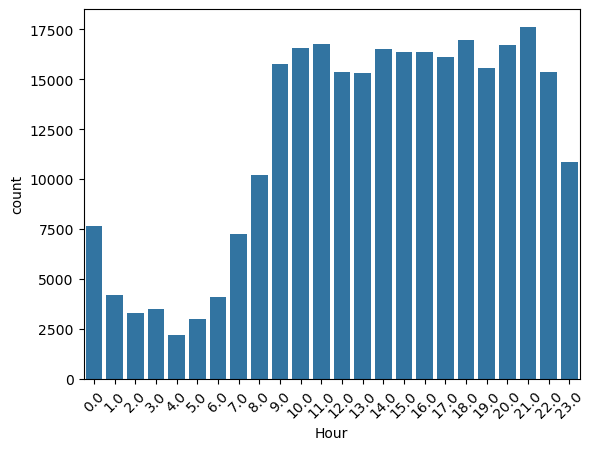

In [22]:
sns.countplot(x='Hour', data=cc)
plt.xticks(rotation=45)
plt.show()

#### Insights
- Fraud activity peaks at specific hours
- customer behaviour follows predictable daily cycle
#### Interpretation
- Anomalies occuring outside normal transaction window should be investigated

<Axes: xlabel='Hour', ylabel='Count'>

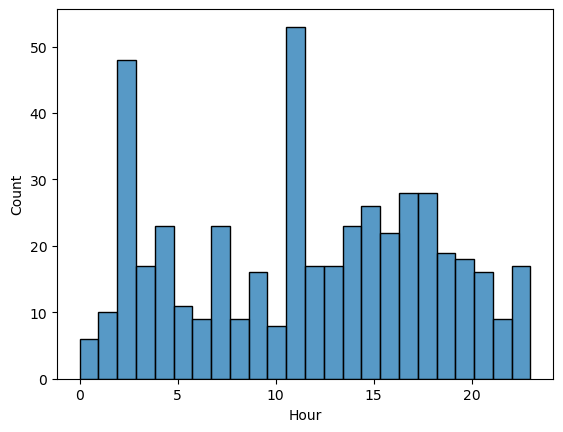

In [23]:
fraud_hour = cc[cc['Class']==1]['Hour']
sns.histplot(fraud_hour, bins=24)

#### Insight
- Fraudulent transactions are not evenly distributed.
- Some hours show noticeably higher fraud concentration.
#### Interpretation
- Time-based monitoring rules can improve fraud prevention systems.

<Axes: >

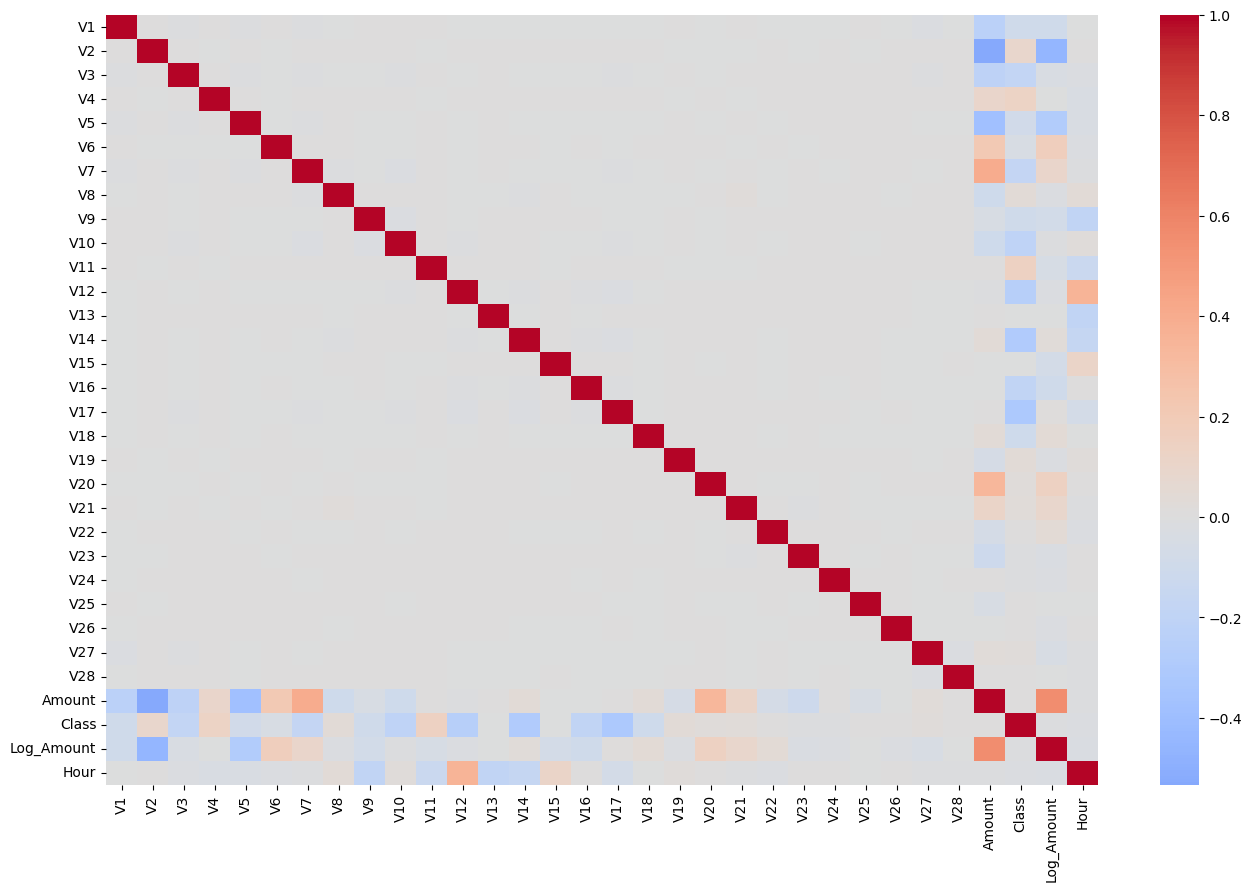

In [24]:
plt.figure(figsize=(16,10))
sns.heatmap(cc.corr(),cmap="coolwarm",center=0)

#### Insight
- Most variables exhibit weak correlations.
- Features appear largely independent.
#### Interpretation
- Independent variables provide diverse information useful for identifying suspicious patterns.

In [25]:
cc['High_Amount'] = cc['Amount'] > 200

#### Insight
- Transactions are segmented into high-value and low-value categories.
- This helps evaluate whether transaction size influences fraud occurrence


In [26]:
cc.groupby("High_Amount")["Class"].mean()*100

High_Amount
False    0.153360
True     0.285019
Name: Class, dtype: float64

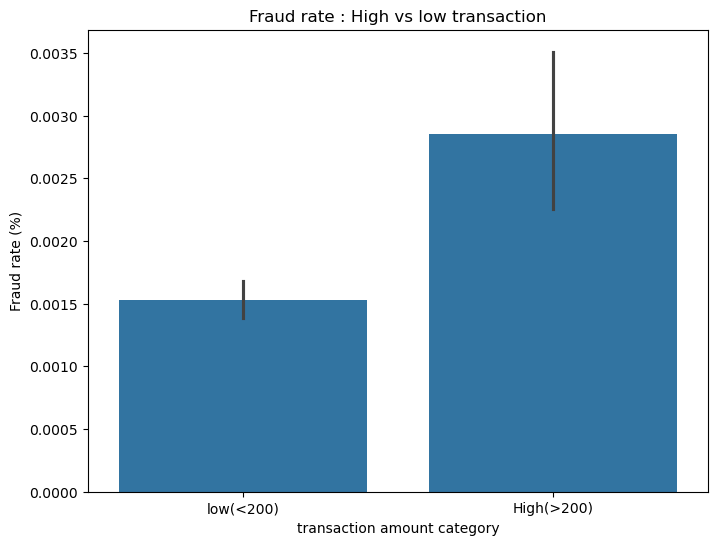

In [27]:
plt.figure(figsize=(8,6))
sns.barplot(x=cc["High_Amount"].map({False : "low(<200)", True: "High(>200)"}),y=cc["Class"])
plt.title("Fraud rate : High vs low transaction")
plt.xlabel("transaction amount category")
plt.ylabel("Fraud rate (%)")
plt.show()

#### Insight
- High-value transactions have a higher fraud rate than low-value transactions.
- Fraud risk increases with transaction amount.
#### Interpretation
- Additional verification measures should be applied to large transactions.

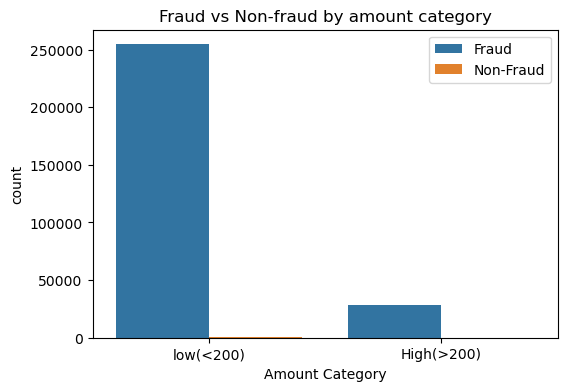

In [28]:
plt.figure(figsize =(6,4))
sns.countplot(x="High_Amount",hue = "Class",data = cc)
plt.title("Fraud vs Non-fraud by amount category")
plt.xlabel('Amount Category')
plt.xticks([0,1],["low(<200)","High(>200)"])
plt.legend(["Fraud","Non-Fraud"])
plt.show()

#### Insight
- Most transactions are low-value.
- Fraud occurs in both categories but is relatively more common among high-value transactions.
#### Interpretation
- Large-value transactions deserve greater scrutiny due to elevated risk.

C:\Users\franc\AppData\Local\Temp\ipykernel_3844\2629929264.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_bin = cc.groupby('Amount_Bin')['Class'].mean() * 100


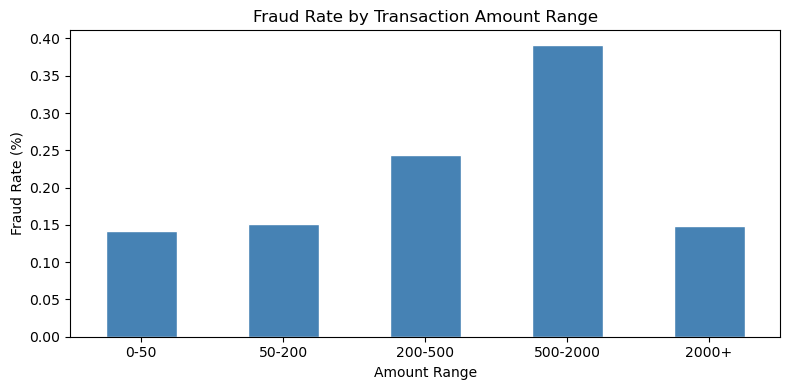

In [29]:
cc['Amount_Bin'] = pd.cut(cc['Amount'], 
                           bins=[0, 50, 200, 500, 2000, cc['Amount'].max()],
                           labels=['0-50', '50-200', '200-500', '500-2000', '2000+'])

fraud_by_bin = cc.groupby('Amount_Bin')['Class'].mean() * 100

plt.figure(figsize=(8, 4))
fraud_by_bin.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Fraud Rate by Transaction Amount Range')
plt.xlabel('Amount Range')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Insight
- Fraud rates vary across transaction ranges.
- Certain amount brackets exhibit higher fraud susceptibility.
#### Interpretation
- Risk-based monitoring strategies can prioritize transaction ranges with higher fraud exposure.

# Model Building

In [30]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

In [31]:
df = cc.copy()

In [32]:
df.shape
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V25,V26,V27,V28,Amount,Class,Log_Amount,Hour,High_Amount,Amount_Bin
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0.0,False,50-200
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,0.0,False,0-50
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,0.0,True,200-500
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0.0,False,50-200
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,0.0,False,50-200


# Cyclic encoding of hour

In [33]:
df['Hour_sin']=np.sin(2*np.pi*df['Hour']/24)
df['Hour_cos']=np.cos(2*np.pi*df['Hour']/24)

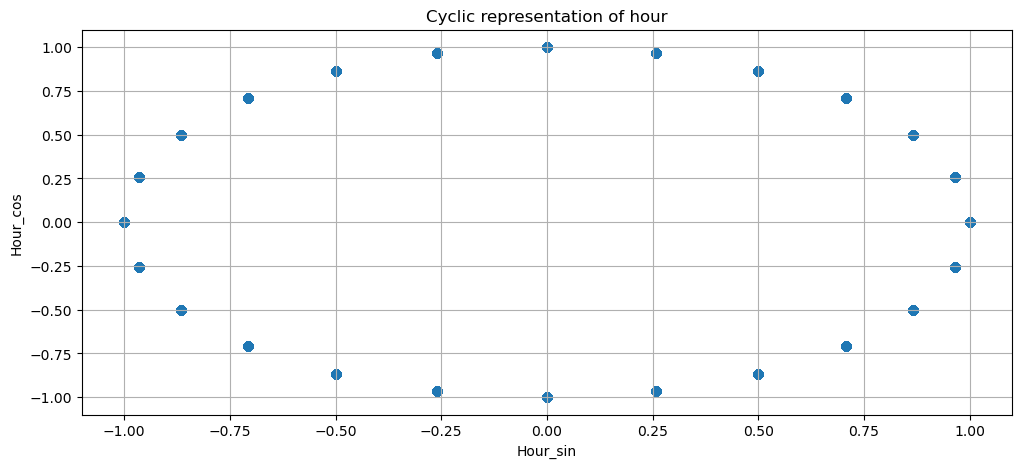

In [34]:
plt.figure(figsize=(12,5))
plt.scatter(df['Hour_sin'],df['Hour_cos'],alpha = 0.4)
plt.xlabel('Hour_sin')
plt.ylabel('Hour_cos')
plt.title('Cyclic representation of hour')
plt.grid(True)

plt.show()

In [35]:
df["V1_V2"] = df["V1"] * df["V2"]
df["V3_V4"] = df["V3"] * df["V4"]
df["V10_V14"] = df["V10"] * df["V14"]

In [36]:
df['Amount_hour']=(df['Amount']*(df['Hour']+1))

In [37]:
scaler = RobustScaler()

In [38]:
scaler_col = ['Amount','Log_Amount']

In [39]:
df[scaler_col]= scaler.fit_transform(df[scaler_col])

In [40]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,Log_Amount,Hour,High_Amount,Amount_Bin,Hour_sin,Hour_cos,V1_V2,V3_V4,V10_V14,Amount_hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.758945,0.0,False,50-200,0.0,1.0,0.098968,3.495480,-0.028252,149.62
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.738995,0.0,False,0-50,0.0,1.0,0.317214,0.074609,0.024006,2.69
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,1.132312,0.0,True,200-500,0.0,1.0,1.820416,0.673429,-0.034457,378.66
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.682029,0.0,False,50-200,0.0,1.0,0.178979,-1.547876,0.015822,123.50
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.455159,0.0,False,50-200,0.0,1.0,-1.016624,0.624186,-0.843195,69.99


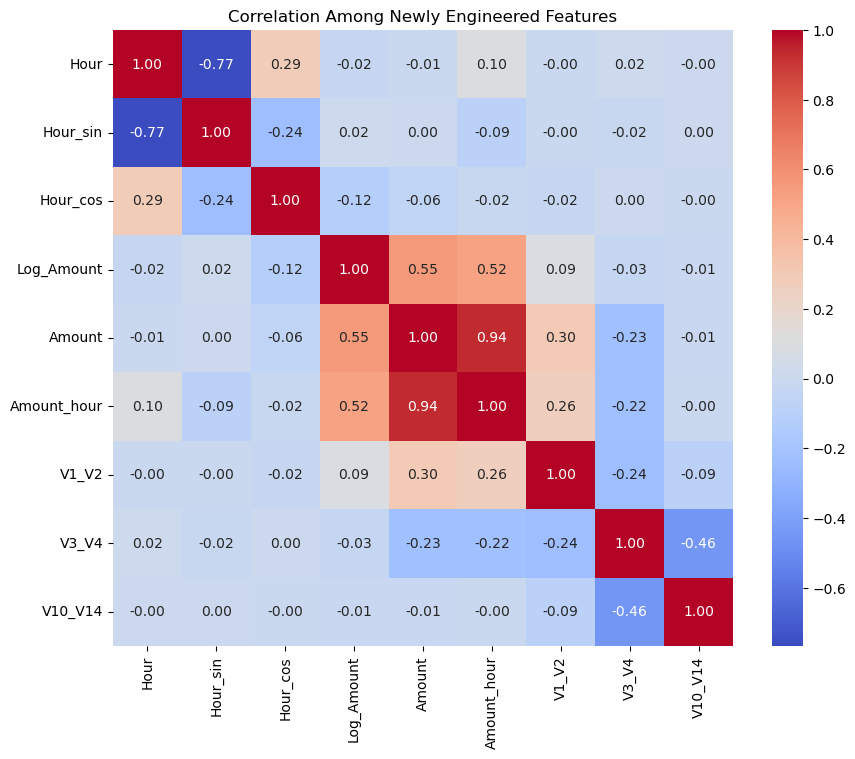

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

new_features = [
    "Hour",
    "Hour_sin",
    "Hour_cos",
    "Log_Amount",
    "Amount",
    "Amount_hour",
    "V1_V2",
    "V3_V4",
    "V10_V14"
]

plt.figure(figsize=(10,8))

sns.heatmap(df[new_features].corr(),annot=True,cmap="coolwarm",
fmt=".2f")

plt.title("Correlation Among Newly Engineered Features")
plt.show()

In [42]:
df.drop(columns=["Hour"], inplace=True)

In [43]:
x = df.drop('Class',axis = 1)
y= df['Class']

In [44]:
print(x.shape)
print(y.shape)

(283726, 38)
(283726,)


In [45]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size = 0.30, stratify = y,random_state = 1)

In [46]:
print("Training Shape :", xtrain.shape)
print("Testing Shape  :", xtest.shape)

Training Shape : (198608, 38)
Testing Shape  : (85118, 38)


In [47]:
print("Training Set")

print(ytrain.value_counts(normalize=True))

print()

print("Testing Set")

print(ytest.value_counts(normalize=True))

Training Set
Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64

Testing Set
Class
0    0.998332
1    0.001668
Name: proportion, dtype: float64


In [48]:
processed_data = {
    "xtrain": xtrain,
    "xtest": xtest,
    "ytrain": ytrain,
    "ytest": ytest
}

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [50]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

In [51]:
xtrain = pd.get_dummies(xtrain, columns=["Amount_Bin"], drop_first=True)
xtest = pd.get_dummies(xtest, columns=["Amount_Bin"], drop_first=True)

In [52]:
models = {"Logistic Regression":LogisticRegression( max_iter=1000, random_state=42),
 "Decision Tree":DecisionTreeClassifier( random_state=42 ),
"Random Forest" : RandomForestClassifier(  n_estimators=200,random_state=42,n_jobs=-1),
 "XGBoost":XGBClassifier( n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss')}

In [53]:
def evaluate_model(model, xtrain, ytrain, xtest, ytest):

    model.fit(xtrain, ytrain)

    pred = model.predict(xtest)
    prob = model.predict_proba(xtest)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(ytest, pred),
        "Balanced Accuracy": balanced_accuracy_score(ytest, pred),
        "Precision": precision_score(ytest, pred),
        "Recall": recall_score(ytest, pred),
        "F1": f1_score(ytest, pred),
        "ROC-AUC": roc_auc_score(ytest, prob),
        "PR-AUC": average_precision_score(ytest, prob),
        "MCC": matthews_corrcoef(ytest, pred)
    }

    return metrics, pred, prob,cm

In [57]:

results = []
predictions = {}
probabilities = {}
trained_models = {}

for name, model in models.items():

    # Train the model
    model.fit(xtrain, ytrain)

    # Save trained model
    trained_models[name] = model

    # Predictions
    pred = model.predict(xtest)
    prob = model.predict_proba(xtest)[:, 1]

    # Save predictions
    predictions[name] = pred
    probabilities[name] = prob

    cm = confusion_matrix(ytest, pred)
    # Metrics
    metric = {
        "Accuracy": accuracy_score(ytest, pred),
        "Precision": precision_score(ytest, pred),
        "Recall": recall_score(ytest, pred),
        "F1": f1_score(ytest, pred),
        "ROC-AUC": roc_auc_score(ytest, prob),
        "PR-AUC": average_precision_score(ytest, prob),
        "Balanced Accuracy": balanced_accuracy_score(ytest, pred),
        "MCC": matthews_corrcoef(ytest, pred)
    }

    results.append({
        "Model": name,
        **metric
    })

# Create results DataFrame
results_df = pd.DataFrame(results)

results_df.sort_values("PR-AUC", ascending=False)

C:\Users\franc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Balanced Accuracy,MCC
3,XGBoost,0.999542,0.947826,0.767606,0.848249,0.976130,0.813630,0.883768,0.852755
2,Random Forest,0.999495,0.938053,0.746479,0.831373,0.933704,0.809288,0.873198,0.836566
0,Logistic Regression,0.999142,0.822430,0.619718,0.706827,0.966816,0.726826,0.809747,0.713511
1,Decision Tree,0.999119,0.759690,0.690141,0.723247,0.844888,0.524810,0.844888,0.723643


In [59]:
baseline_results=pd.DataFrame(results)

baseline_results=baseline_results[

[
"Model",
"Accuracy",
"Balanced Accuracy",
"Precision",
"Recall",
"F1",
"ROC-AUC",
"PR-AUC",
"MCC"
]

]

baseline_results.sort_values(
    by="Recall",
    ascending=False
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC
3,XGBoost,0.999542,0.883768,0.947826,0.767606,0.848249,0.976130,0.813630,0.852755
2,Random Forest,0.999495,0.873198,0.938053,0.746479,0.831373,0.933704,0.809288,0.836566
1,Decision Tree,0.999119,0.844888,0.759690,0.690141,0.723247,0.844888,0.524810,0.723643
0,Logistic Regression,0.999142,0.809747,0.822430,0.619718,0.706827,0.966816,0.726826,0.713511


In [60]:
def plot_confusion(y_true,pred,title):

    cm=confusion_matrix(y_true,pred)

    plt.figure(figsize=(5,4))

    sns.heatmap( cm, annot=True, fmt="d", cmap="Blues")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.title(title)

    plt.show()

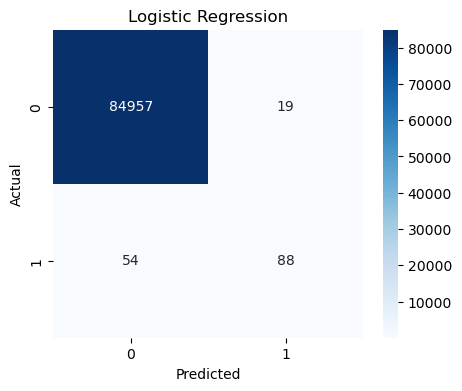

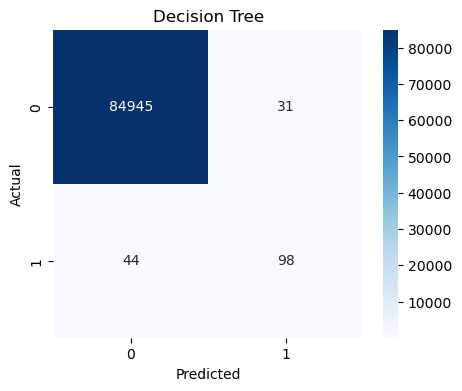

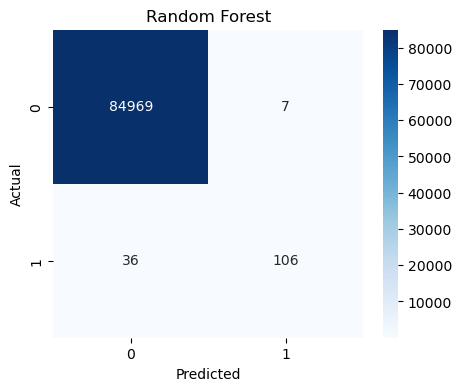

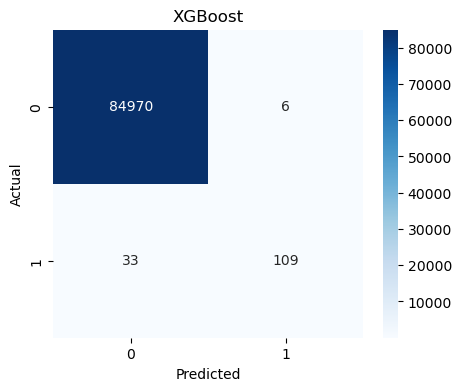

In [61]:
for model_name,pred in predictions.items():

    plot_confusion(ytest, pred, model_name)

In [62]:
for model_name,pred in predictions.items():

    print("="*60)

    print(model_name)

    print()

    print(classification_report(ytest,pred))

Logistic Regression

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.82      0.62      0.71       142

    accuracy                           1.00     85118
   macro avg       0.91      0.81      0.85     85118
weighted avg       1.00      1.00      1.00     85118

Decision Tree

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.76      0.69      0.72       142

    accuracy                           1.00     85118
   macro avg       0.88      0.84      0.86     85118
weighted avg       1.00      1.00      1.00     85118

Random Forest

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.94      0.75      0.83       142

    accuracy                           1.00     85118
   macro avg       0.97      0.87      0.92     85118
weighted avg       1.00

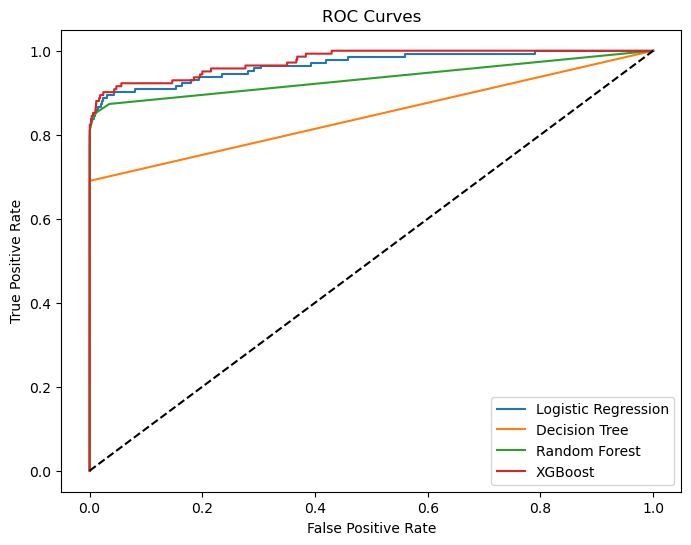

In [63]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name in models.keys():

    fpr,tpr,_=roc_curve( ytest, probabilities[name])

    plt.plot(fpr,tpr,label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.show()

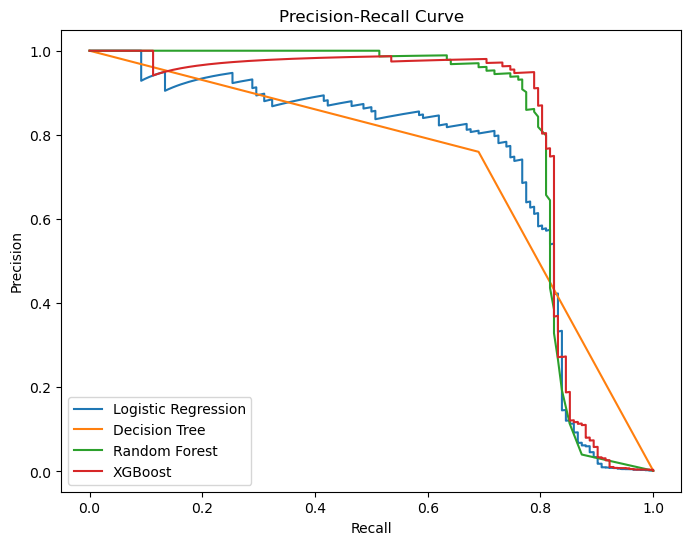

In [64]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for name in models.keys():

    precision,recall,_=precision_recall_curve(ytest,probabilities[name])

    plt.plot(recall,precision, label=name)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

# Handling class imbalance with smote


In [67]:
print(ytrain.value_counts())

print(ytrain.value_counts(normalize=True))

Class
0    198277
1       331
Name: count, dtype: int64
Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64


In [68]:
from imblearn.over_sampling import (RandomOverSampler,SMOTE,BorderlineSMOTE,ADASYN)
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import (SMOTETomek,SMOTEENN)

In [71]:
smote = SMOTE(random_state =1)

In [72]:
xtrain_res,ytrain_res = smote.fit_resample(xtrain,ytrain)

In [73]:
ytrain.value_counts()

Class
0    198277
1       331
Name: count, dtype: int64

In [74]:
ytrain_res.value_counts()

Class
0    198277
1    198277
Name: count, dtype: int64

In [75]:
models = {"Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost" : XGBClassifier()}

# Model training after smote

In [78]:
model.fit(xtrain_res,ytrain_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [80]:
y_pred = model.predict(xtest)
y_prob = model.predict_proba(xtest)[:,1]

In [82]:
accuracy = accuracy_score(ytest, y_pred)
precision = precision_score(ytest, y_pred)
recall = recall_score(ytest, y_pred)
f1 = f1_score(ytest, y_pred)
roc_auc = roc_auc_score(ytest, y_prob)
pr_auc = average_precision_score(ytest, y_prob)
mcc = matthews_corrcoef(ytest, y_pred)
balanced_acc = balanced_accuracy_score(ytest, y_pred)

In [83]:
print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"ROC-AUC           : {roc_auc:.4f}")
print(f"PR-AUC            : {pr_auc:.4f}")
print(f"MCC               : {mcc:.4f}")
print(f"Balanced Accuracy : {balanced_acc:.4f}")

Accuracy          : 0.9994
Precision         : 0.8273
Recall            : 0.8099
F1 Score          : 0.8185
ROC-AUC           : 0.9720
PR-AUC            : 0.8181
MCC               : 0.8183
Balanced Accuracy : 0.9048


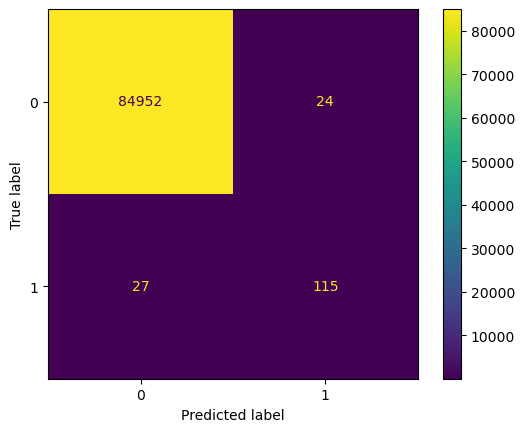

In [85]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(ytest, y_pred)

ConfusionMatrixDisplay(cm).plot()
plt.show()

In [87]:
print(classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.83      0.81      0.82       142

    accuracy                           1.00     85118
   macro avg       0.91      0.90      0.91     85118
weighted avg       1.00      1.00      1.00     85118



In [92]:
smote_results = []
smote_results.append({
    "Model": model_name,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc,
    "MCC": mcc,
    "Balanced Accuracy": balanced_acc
})

# performance evaluation after smote

In [94]:
smote_results = pd.DataFrame(smote_results)
smote_results.sort_values("PR-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC,Balanced Accuracy
0,XGBoost,0.999401,0.827338,0.809859,0.818505,0.971963,0.81815,0.818252,0.904788


In [95]:
comparison = pd.concat([baseline_results, smote_results], ignore_index=True)
comparison

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC
0,Logistic Regression,0.999142,0.809747,0.822430,0.619718,0.706827,0.966816,0.726826,0.713511
1,Decision Tree,0.999119,0.844888,0.759690,0.690141,0.723247,0.844888,0.524810,0.723643
2,Random Forest,0.999495,0.873198,0.938053,0.746479,0.831373,0.933704,0.809288,0.836566
3,XGBoost,0.999542,0.883768,0.947826,0.767606,0.848249,0.976130,0.813630,0.852755
4,XGBoost,0.999401,0.904788,0.827338,0.809859,0.818505,0.971963,0.818150,0.818252


# Conclusion


- Performed Exploratory Data Analysis (EDA) to understand the dataset, identify class imbalance, and analyze transaction patterns.
- Applied data preprocessing and feature engineering, including scaling and creation of relevant features, to improve model performance.
- Trained and evaluated multiple machine learning models using metrics such as Accuracy, Precision, Recall, F1-score, ROC-AUC, PR-AUC, Balanced Accuracy, and MCC.
- Addressed the severe class imbalance by applying SMOTE only to the training data, ensuring that the test data remained unchanged.
- Compared model performance before and after SMOTE to assess the impact of oversampling on fraud detection.
- Observed that SMOTE improved the model's ability to detect fraudulent transactions by increasing Recall, making the model more effective at identifying fraud cases.
- Selected the best-performing model based on a combination of Recall, F1-score, PR-AUC, and ROC-AUC, which are more suitable metrics than Accuracy for highly imbalanced datasets.
- The final model demonstrates that combining feature engineering, class imbalance handling, and appropriate evaluation metrics results in a more reliable and robust credit card fraud detection system.

#### XGBoost with smote has  achieved the best overall performance and was selected as the final model for credit card fraud detection due to its strong balance between fraud detection capability and overall predictive performance.